In [4]:
import random
from pathlib import Path
from segmentflow import segment, view

This notebook is special in that it can be run multiple times to create new
subvolumes that will be saved as additional volumes to the project directory.

In [7]:
user = (
    'cgusb' if 'cgusb' in [f.stem for f in Path(r"C:\Users").iterdir()]
    else 'gusb'
)
img_dir = Path(
    fr'C:\Users\{user}\Research\mhe-analysis\results'
    fr'\prill_1_0.25-scale_segmented\prill_1_0.25-scale_labeled_voxels'
)
labeled_imgs = segment.load_images(img_dir, file_suffix='.tif')

Loading images...
--> Images loaded as 3D array:  (498, 508, 496)


In [8]:
# Create project directory, if it doesn't exist
save_dir = Path(
    fr'C:\Users\{user}\Research\mhe-analysis\results'
    fr'\prill_1_0.25-scale_subvolumes')
if not save_dir.is_dir():
    save_dir.mkdir()

Downscale set to: 2
--> Plotting images: [  0 124 248 372 497]


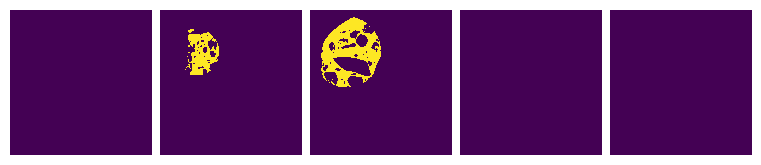

In [76]:
# Set downscale factor
downscale = random.choice([2, 5, 10])
print('Downscale set to:', downscale)
# Get mask
mask = segment.get_spherical_mask(
    labeled_imgs, factor=downscale, loc_range_frac=(0, 3/4))
# Apply mask to labeled_imgs
subvol = mask * labeled_imgs
fig, axes = view.vol_slices(subvol==1, nslices=5)

In [ ]:
save_subvol = False
# save_subvol = True
if save_subvol:
    save_dir_list = [f for f in save_dir.iterdir()]
    subvol_i = len(save_dir_list)
    # Create directory for subvolume
    subvol_name = f'{str(subvol_i).zfill(2)}_subvol_downscale-{downscale}'
    subvol_dir = Path(save_dir) / subvol_name
    print(f'subvolume name: {subvol_name}')
    subvol_dir.mkdir()
    # Save voxels
    voxel_save_dir = Path(subvol_dir) / f"{subvol_name}_labeled_voxels"
    segment.save_images(subvol, voxel_save_dir)
    # Save STLs
    stl_save_dir = Path(subvol_dir) / f"{subvol_name}_STLs"
    segment.save_as_stl_files(
        subvol, stl_save_dir, subvol_name, make_new_save_dir=False)

subvolume name: 09_subvol_downscale-10
498 image(s) saved to: C:\Users\gusb\Research\mhe-analysis\results\prill_1_0.25-scale_subvolumes\09_subvol_downscale-10\09_subvol_downscale-10_labeled_voxels
Generating surface meshes...
Surface mesh not created for particle 13387. Particle likely too small. Error: No surface found at the given iso value.
Surface mesh not created for particle 13731. Particle likely too small. Error: No surface found at the given iso value.
Surface mesh not created for particle 14195. Particle likely too small. Error: No surface found at the given iso value.
--> 18 STL file(s) written!
